# The Ten Best Days \U0001F4C6
### The statistic is true. The argument built on it is not.

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)

You have seen the chart. A bar for buy-and-hold, then shorter bars for missing the best 10, 20,
30 days, and a caption about the perils of market timing. Every number on it is right. Three
things are missing, and each of them points the other way.

> \U0001F4D3 **This is the plain-language layer.** The shuffle test, the synthetic control and
> the break-even calculation are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Is the ten-best-days number true? | Yes. |
| Is there a ten-worst-days number? | Yes, and it is bigger. |
| Can you miss one set without the other? | No — they are days apart. |
| So should you time the market? | Almost certainly not, for a better reason. |

## 1 · The chart you have seen

In [2]:
from bestdays import data, strategy as st

px = data.load_prices()
r = px[data.EQUITY].dropna().pct_change().dropna()
print(f"as-of {data.AS_OF} | {data.EQUITY}: {len(r):,} sessions from "
      f"{r.index[0].date()} ({len(r)/252:.1f} years)")
print(f"buy and hold: {st.annualised(r):.2%} a year")

as-of 2026-06-30 | SPY: 8,410 sessions from 1993-02-01 (33.4 years)
buy and hold: 10.83% a year


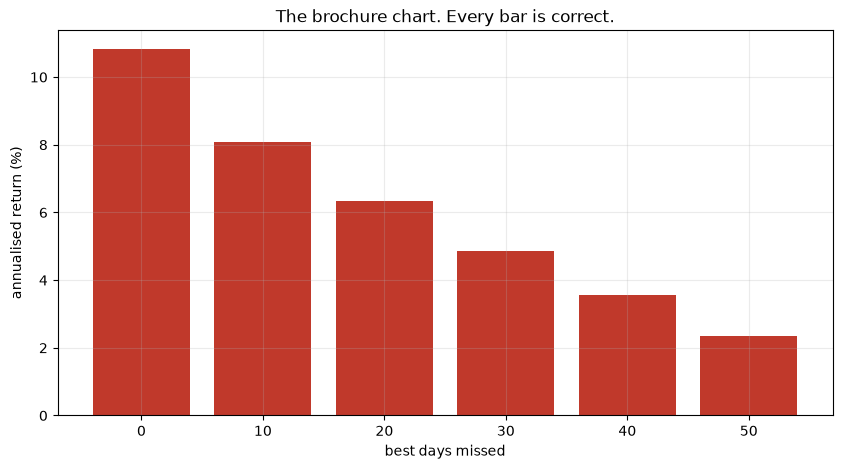

      miss_best_cagr
days                
0             0.1083
10            0.0810
20            0.0633
30            0.0485
40            0.0355
50            0.0236


In [3]:
t = st.missed_days_table(r, counts=(0, 10, 20, 30, 40, 50))
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([str(i) for i in t.index], t["miss_best_cagr"] * 100, color="#c0392b")
ax.set_xlabel("best days missed"); ax.set_ylabel("annualised return (%)")
ax.set_title("The brochure chart. Every bar is correct.")
plt.show()
print(t[["miss_best_cagr"]].round(4).to_string())

## 2 · The chart you have not seen

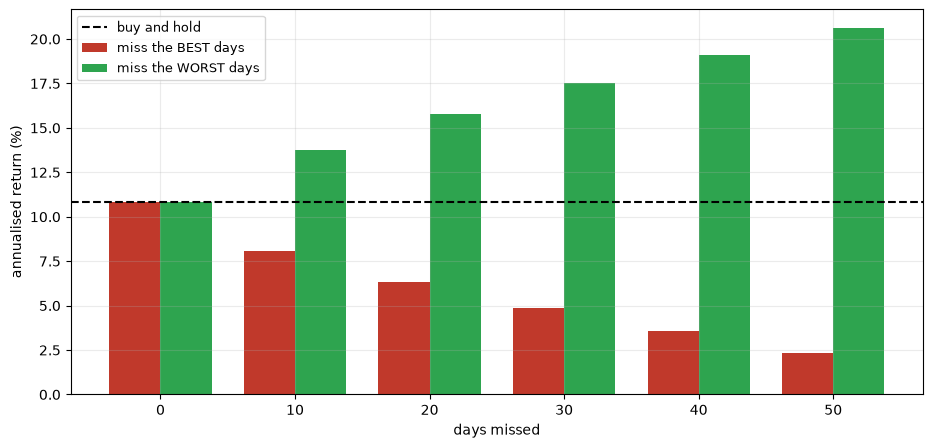

missing the 10 best costs  2.74% a year
missing the 10 worst gains 2.94% a year
the omitted half is 1.07x the size of the quoted one


In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(t)); w = 0.38
ax.bar(x - w/2, t["miss_best_cagr"] * 100, w, color="#c0392b", label="miss the BEST days")
ax.bar(x + w/2, t["miss_worst_cagr"] * 100, w, color="#2ea44f",
       label="miss the WORST days")
ax.axhline(st.annualised(r) * 100, color="k", ls="--", lw=1.5, label="buy and hold")
ax.set_xticks(x); ax.set_xticklabels([str(i) for i in t.index])
ax.set_xlabel("days missed"); ax.set_ylabel("annualised return (%)")
ax.legend(fontsize=9)
plt.show()
a = st.asymmetry(r, 10)
print(f"missing the 10 best costs  {a['cost_of_missing_best']:.2%} a year")
print(f"missing the 10 worst gains {a['benefit_of_missing_worst']:.2%} a year")
print(f"the omitted half is {a['ratio']:.2f}x the size of the quoted one")

The green bars are the same calculation with the sign flipped. They are taller, because the
worst days are bigger than the best days. Nobody prints the green bars.

## 3 · You cannot have one without the other

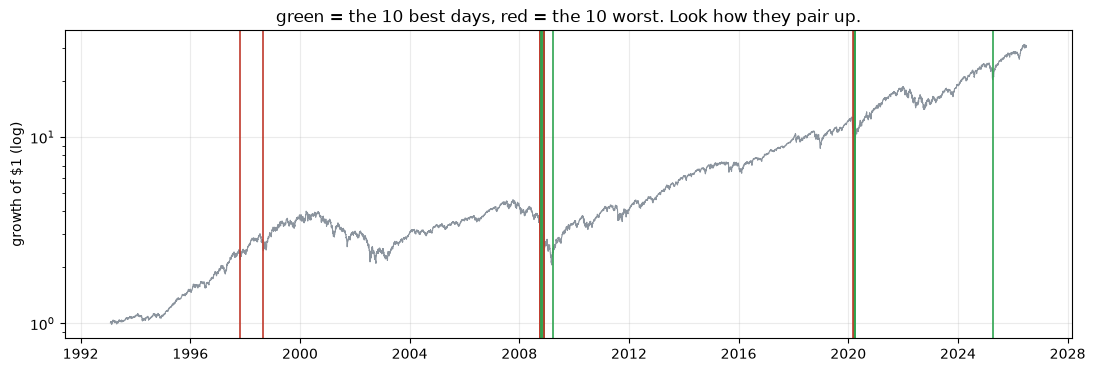

      date     ret  kind  pos
1997-10-27 -0.0725 worst 1198
1998-08-31 -0.0713 worst 1410
2008-09-29 -0.0784 worst 3945
2008-10-09 -0.0698 worst 3953
2008-10-13  0.1452  best 3955
2008-10-15 -0.0984 worst 3957
2008-10-20  0.0601  best 3960
2008-10-28  0.1169  best 3966
2008-11-13  0.0623  best 3978
2008-11-20 -0.0742 worst 3983
2008-11-24  0.0693  best 3985
2008-12-01 -0.0886 worst 3989
2009-03-23  0.0718  best 4065
2020-03-09 -0.0781 worst 6824
2020-03-12 -0.0957 worst 6827
2020-03-13  0.0855  best 6828
2020-03-16 -0.1094 worst 6829
2020-03-24  0.0906  best 6835
2020-04-06  0.0672  best 6844
2025-04-09  0.1050  best 8103


In [5]:
ex = st.extreme_days(r, 10)
fig, ax = plt.subplots(figsize=(13, 4))
eq = (1 + r).cumprod()
ax.semilogy(eq.index, eq.to_numpy(), color="#8b949e", lw=0.8)
for _, row in ex.iterrows():
    ax.axvline(row["date"], color="#2ea44f" if row["kind"] == "best" else "#c0392b",
               lw=1.4, alpha=0.85)
ax.set_ylabel("growth of $1 (log)")
ax.set_title("green = the 10 best days, red = the 10 worst. Look how they pair up.")
plt.show()
print(ex.assign(date=ex["date"].dt.date).to_string(index=False))

> \U0001F52C **For the quants.** The next notebook shuffles the same returns — keeping every
> value, and the fat tail with it — and shows the median best-to-worst distance jumping from a
> handful of sessions to hundreds. The proximity is in the *order*, not the distribution.

## 4 · Missing days at random costs nothing

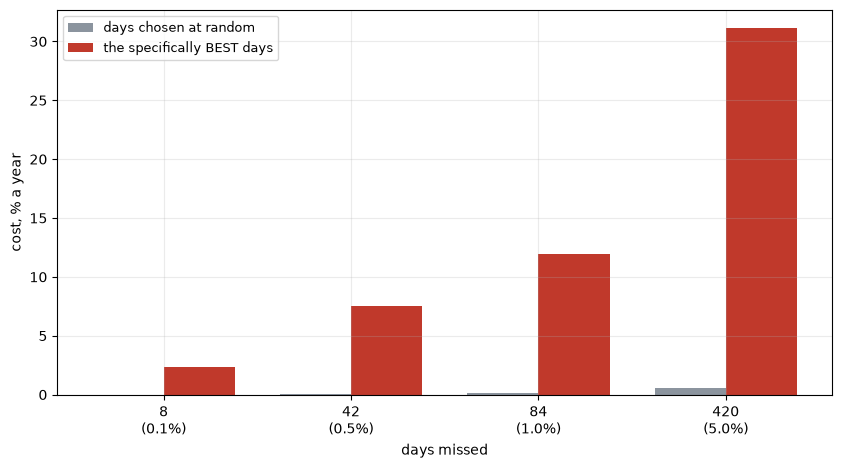

,days,random_cost,worst_case_cost
fraction,,,
0.0010,8,0.0001,0.0235
0.0050,42,0.0005,0.0753
0.0100,84,0.0018,0.1193
0.0500,420,0.0058,0.3115


In [6]:
oc = st.out_of_market_cost(r, fractions=(0.001, 0.005, 0.01, 0.05), n_draws=250)
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(oc)); w = 0.38
ax.bar(x - w/2, oc["random_cost"] * 100, w, color="#8b949e", label="days chosen at random")
ax.bar(x + w/2, oc["worst_case_cost"] * 100, w, color="#c0392b",
       label="the specifically BEST days")
ax.set_xticks(x)
ax.set_xticklabels([f"{int(d):,}\n({f:.1%})" for f, d in zip(oc.index, oc["days"])])
ax.set_xlabel("days missed"); ax.set_ylabel("cost, % a year"); ax.legend(fontsize=9)
plt.show()
oc[["days", "random_cost", "worst_case_cost"]].round(4)

The grey bars are what happens to someone who is out of the market for reasons unrelated to
returns. The red bars are the brochure. They are not the same claim.

## 5 · The question worth asking

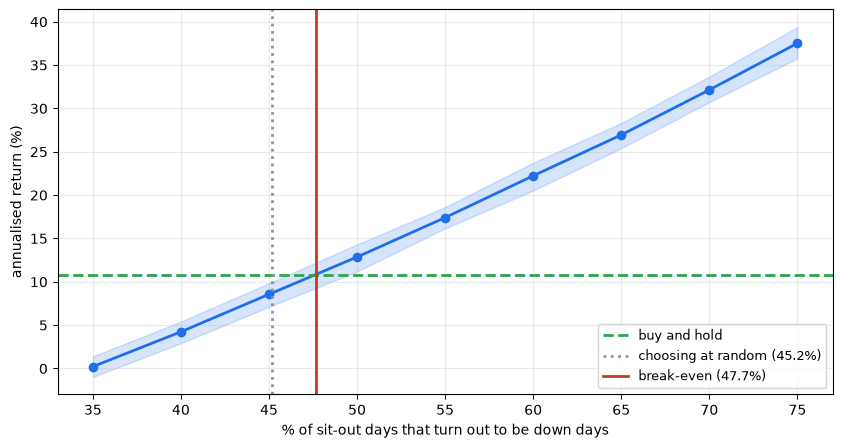

a timer sitting out 20% of days needs 47.68% accuracy to break even
picking at random already gives 45.16% -- so the edge required is 2.5 percentage points


In [7]:
rate = st.down_day_share(r)
f = st.timing_frontier(r, 0.20, np.arange(0.35, 0.76, 0.05), n_draws=250)
base = f["buy_and_hold"].iloc[0]
be = st.breakeven_hit_rate(r, 0.20)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(f.index * 100, f["median_cagr"] * 100, "o-", lw=2, color="#1f6feb")
ax.fill_between(f.index * 100, f["p10"] * 100, f["p90"] * 100, alpha=0.18,
                color="#1f6feb")
ax.axhline(base * 100, color="#2ea44f", ls="--", lw=2, label="buy and hold")
ax.axvline(rate * 100, color="#8b949e", ls=":", lw=2,
           label=f"choosing at random ({rate:.1%})")
ax.axvline(be * 100, color="#c0392b", ls="-", lw=2, label=f"break-even ({be:.1%})")
ax.set_xlabel("% of sit-out days that turn out to be down days")
ax.set_ylabel("annualised return (%)"); ax.legend(fontsize=9)
plt.show()
print(f"a timer sitting out 20% of days needs {be:.2%} accuracy to break even")
print(f"picking at random already gives {rate:.2%} -- so the edge required is "
      f"{(be - rate) * 100:.1f} percentage points")

## 6 · The verdict

**Signal: Real.** The arithmetic is correct. On SPY over 33 years, missing the ten best sessions cuts the annualised return from 10.83% to 8.10% — a loss of **2.74% a year** from ten days out of 8,410. The brochure stops there. Missing the ten **worst** sessions raises it to 13.78%, a gain of **2.94% a year** — **1.07× the size of the loss**. The reason is not the one you would guess. In percentage terms the ten best days are the *bigger* ones (+8.74% against -8.36%), so "crashes are larger than rallies" is simply false here. The asymmetry survives because compounding is multiplicative: removing a day multiplies the result by 1/(1+x), so the quantity that matters is log(1+x) — and in log terms the worst days are the larger (-0.0875 against +0.0835). And the two sets are not scattered through history: the median distance from a best day to the nearest worst day is **6 sessions**, against 290 when the same returns are shuffled (p = 0.000). They arrive in the same storms — the best days occurred at a median drawdown of -34.7% and in volatility 5.8× normal. Being absent for all ten best days while present for all ten worst is not an outcome any rule can produce.

**Tradability: Fragile.** Which makes the interesting question the one nobody asks: how accurate would a timer need to be? Take a rule that sits out 20% of all sessions — 1,682 days — and score it on the share of those days that turn out to be down days. **Choosing at random already achieves 45.2%**, the unconditional down-day frequency, so that and not 50% is the benchmark. Break-even against buy-and-hold arrives at **47.7%**, an edge of only **2.5 percentage points** over random. That sounds modest, and the modesty is the trap: the frontier is savagely steep on both sides. Random selection — sitting out 20% of days with no skill whatsoever — returns 8.59% against buy-and-hold's 10.83%, and a timer 5 points *below* random gets 4.40%. The edge must be small, positive, and sustained across every one of 1,682 decisions; being slightly wrong is far more expensive than being slightly right is profitable. For scale, missing 84 days chosen at random costs 0.12% a year while missing the 84 *best* costs 11.93% — the brochure quotes the worst case of a selection no process generates.

## 7 · Going further \U0001F6AA

- **The conclusion survives.** Staying invested is very probably right. It just is not right for
  the reason the chart gives, and an argument that collapses under its own symmetric twin is
  worth replacing with one that does not.
- **The real argument** is section 5: a timer needs an accuracy that essentially nobody has
  demonstrated, and the best days arrive at the bottom of crashes when a nervous investor is
  least likely to be present.
- **Ask for the other column.** Any time a table shows what happens when you miss the best of
  something, the same table for the worst exists and was not shown.